In [ ]:
import pandas as pd
import warnings
warnings.simplefilter('ignore')
df=pd.read_csv("mushroom.csv")
df

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,1160,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,411,bell,smooth,white,no,pungent,free,close,narrow,orange,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199


In [ ]:
# Step 2: Data Exploration
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [ ]:
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


In [ ]:
#Task 2: Data Preprocessing
# Step 1: Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in df.columns:
    df[column] = label_encoder.fit_transform(df[column])

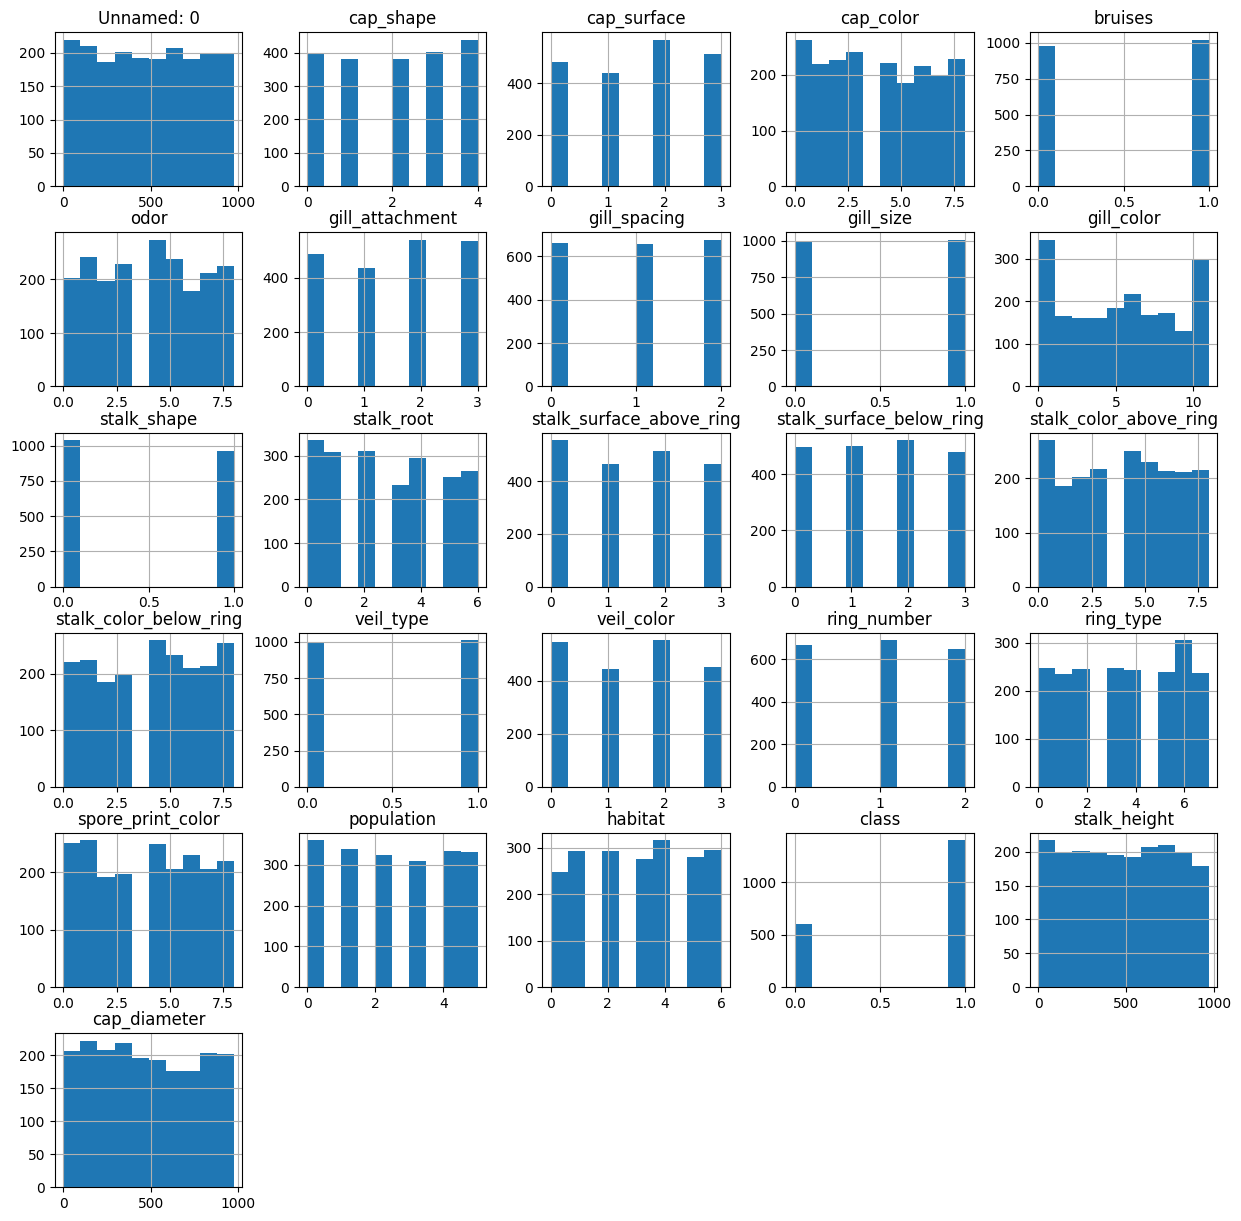

In [ ]:
#Task 1 : 2. Plotting histograms
import matplotlib.pyplot as plt
df.hist(figsize=(15, 15))
plt.show()

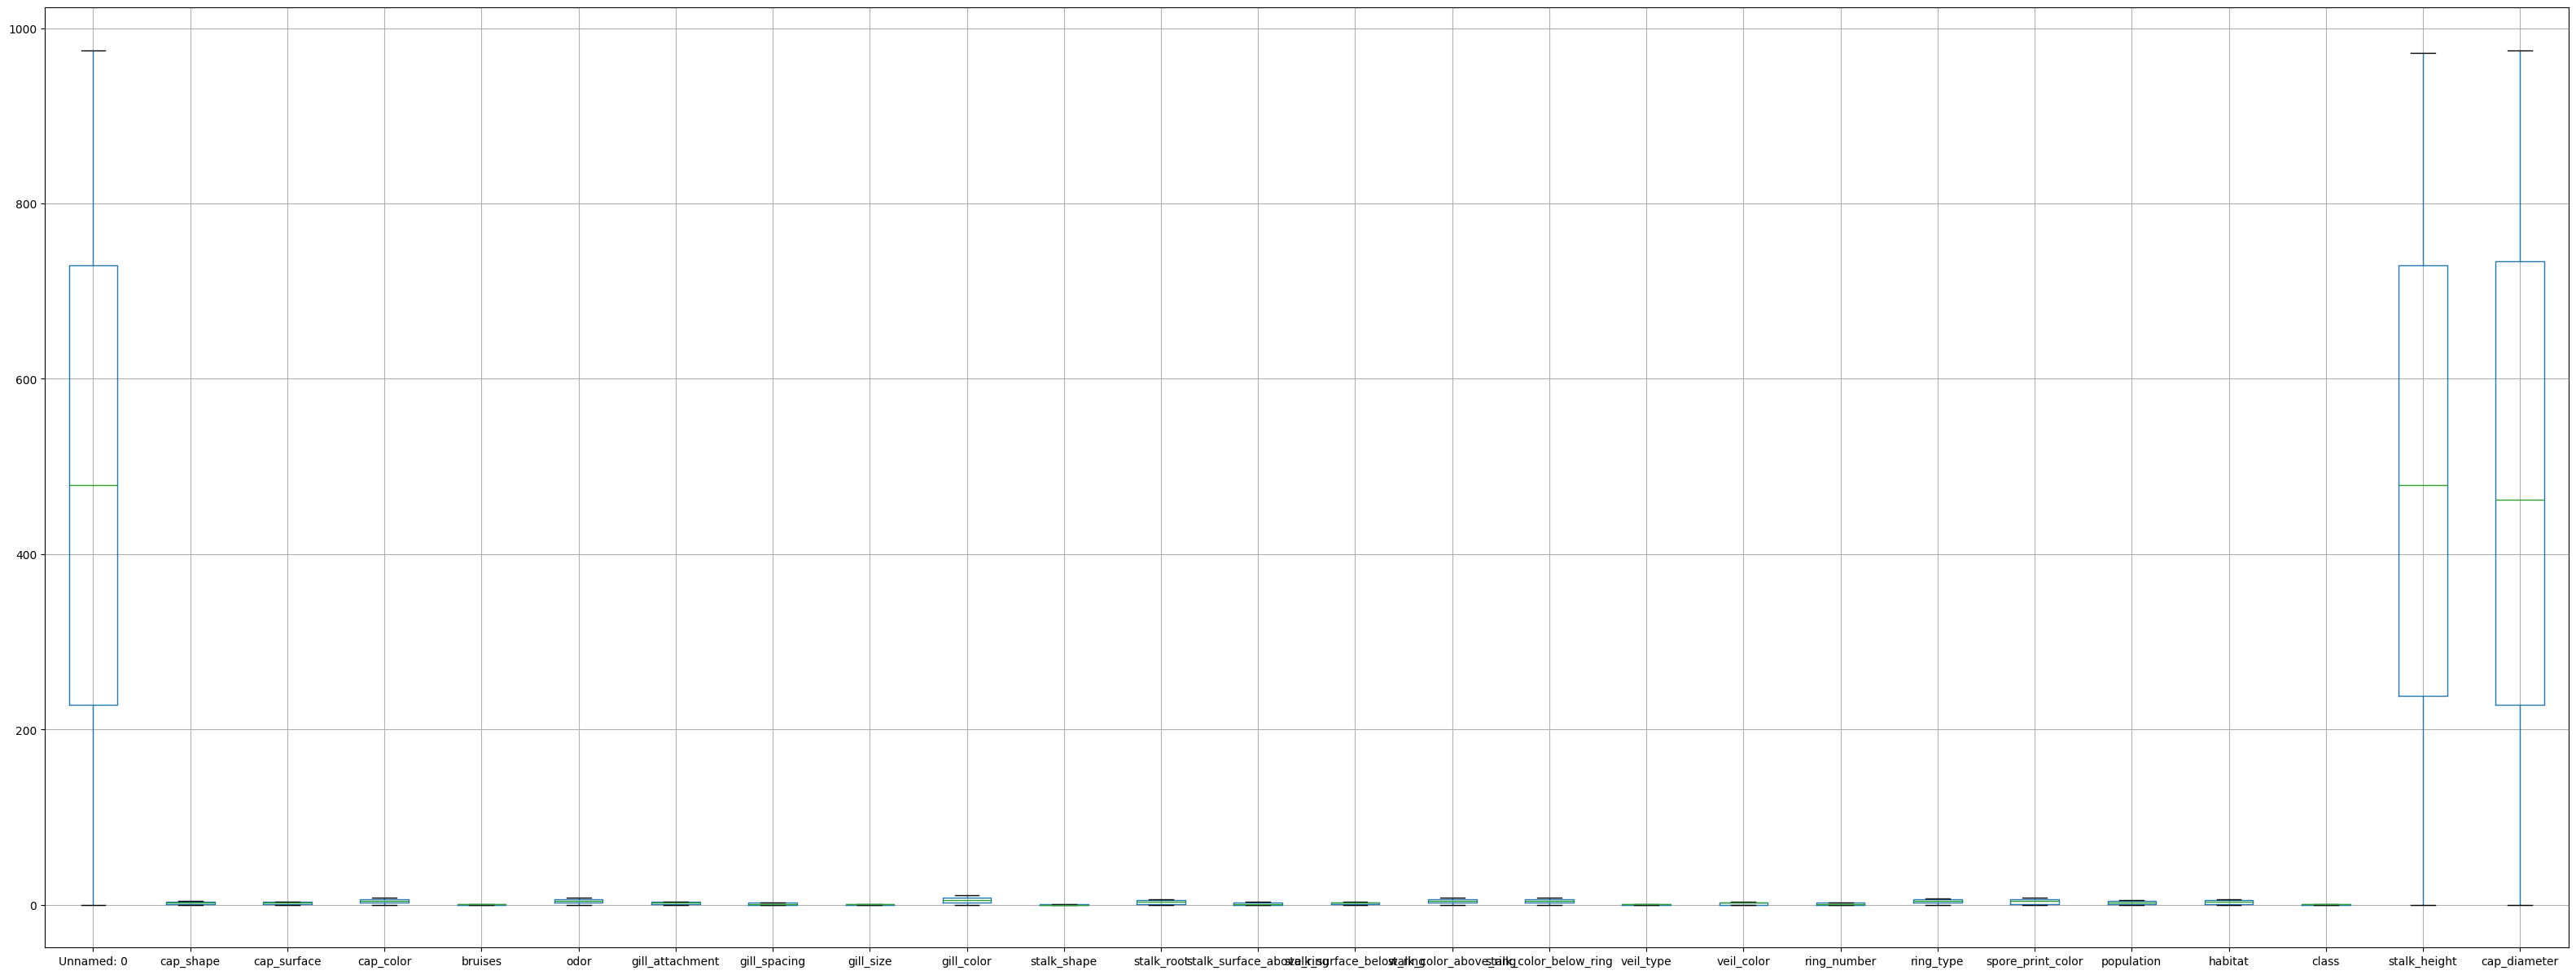

In [ ]:
#Task 1 : 2.plotting boxplot
plt.figure(figsize=(40, 15))
df.boxplot()
plt.show()

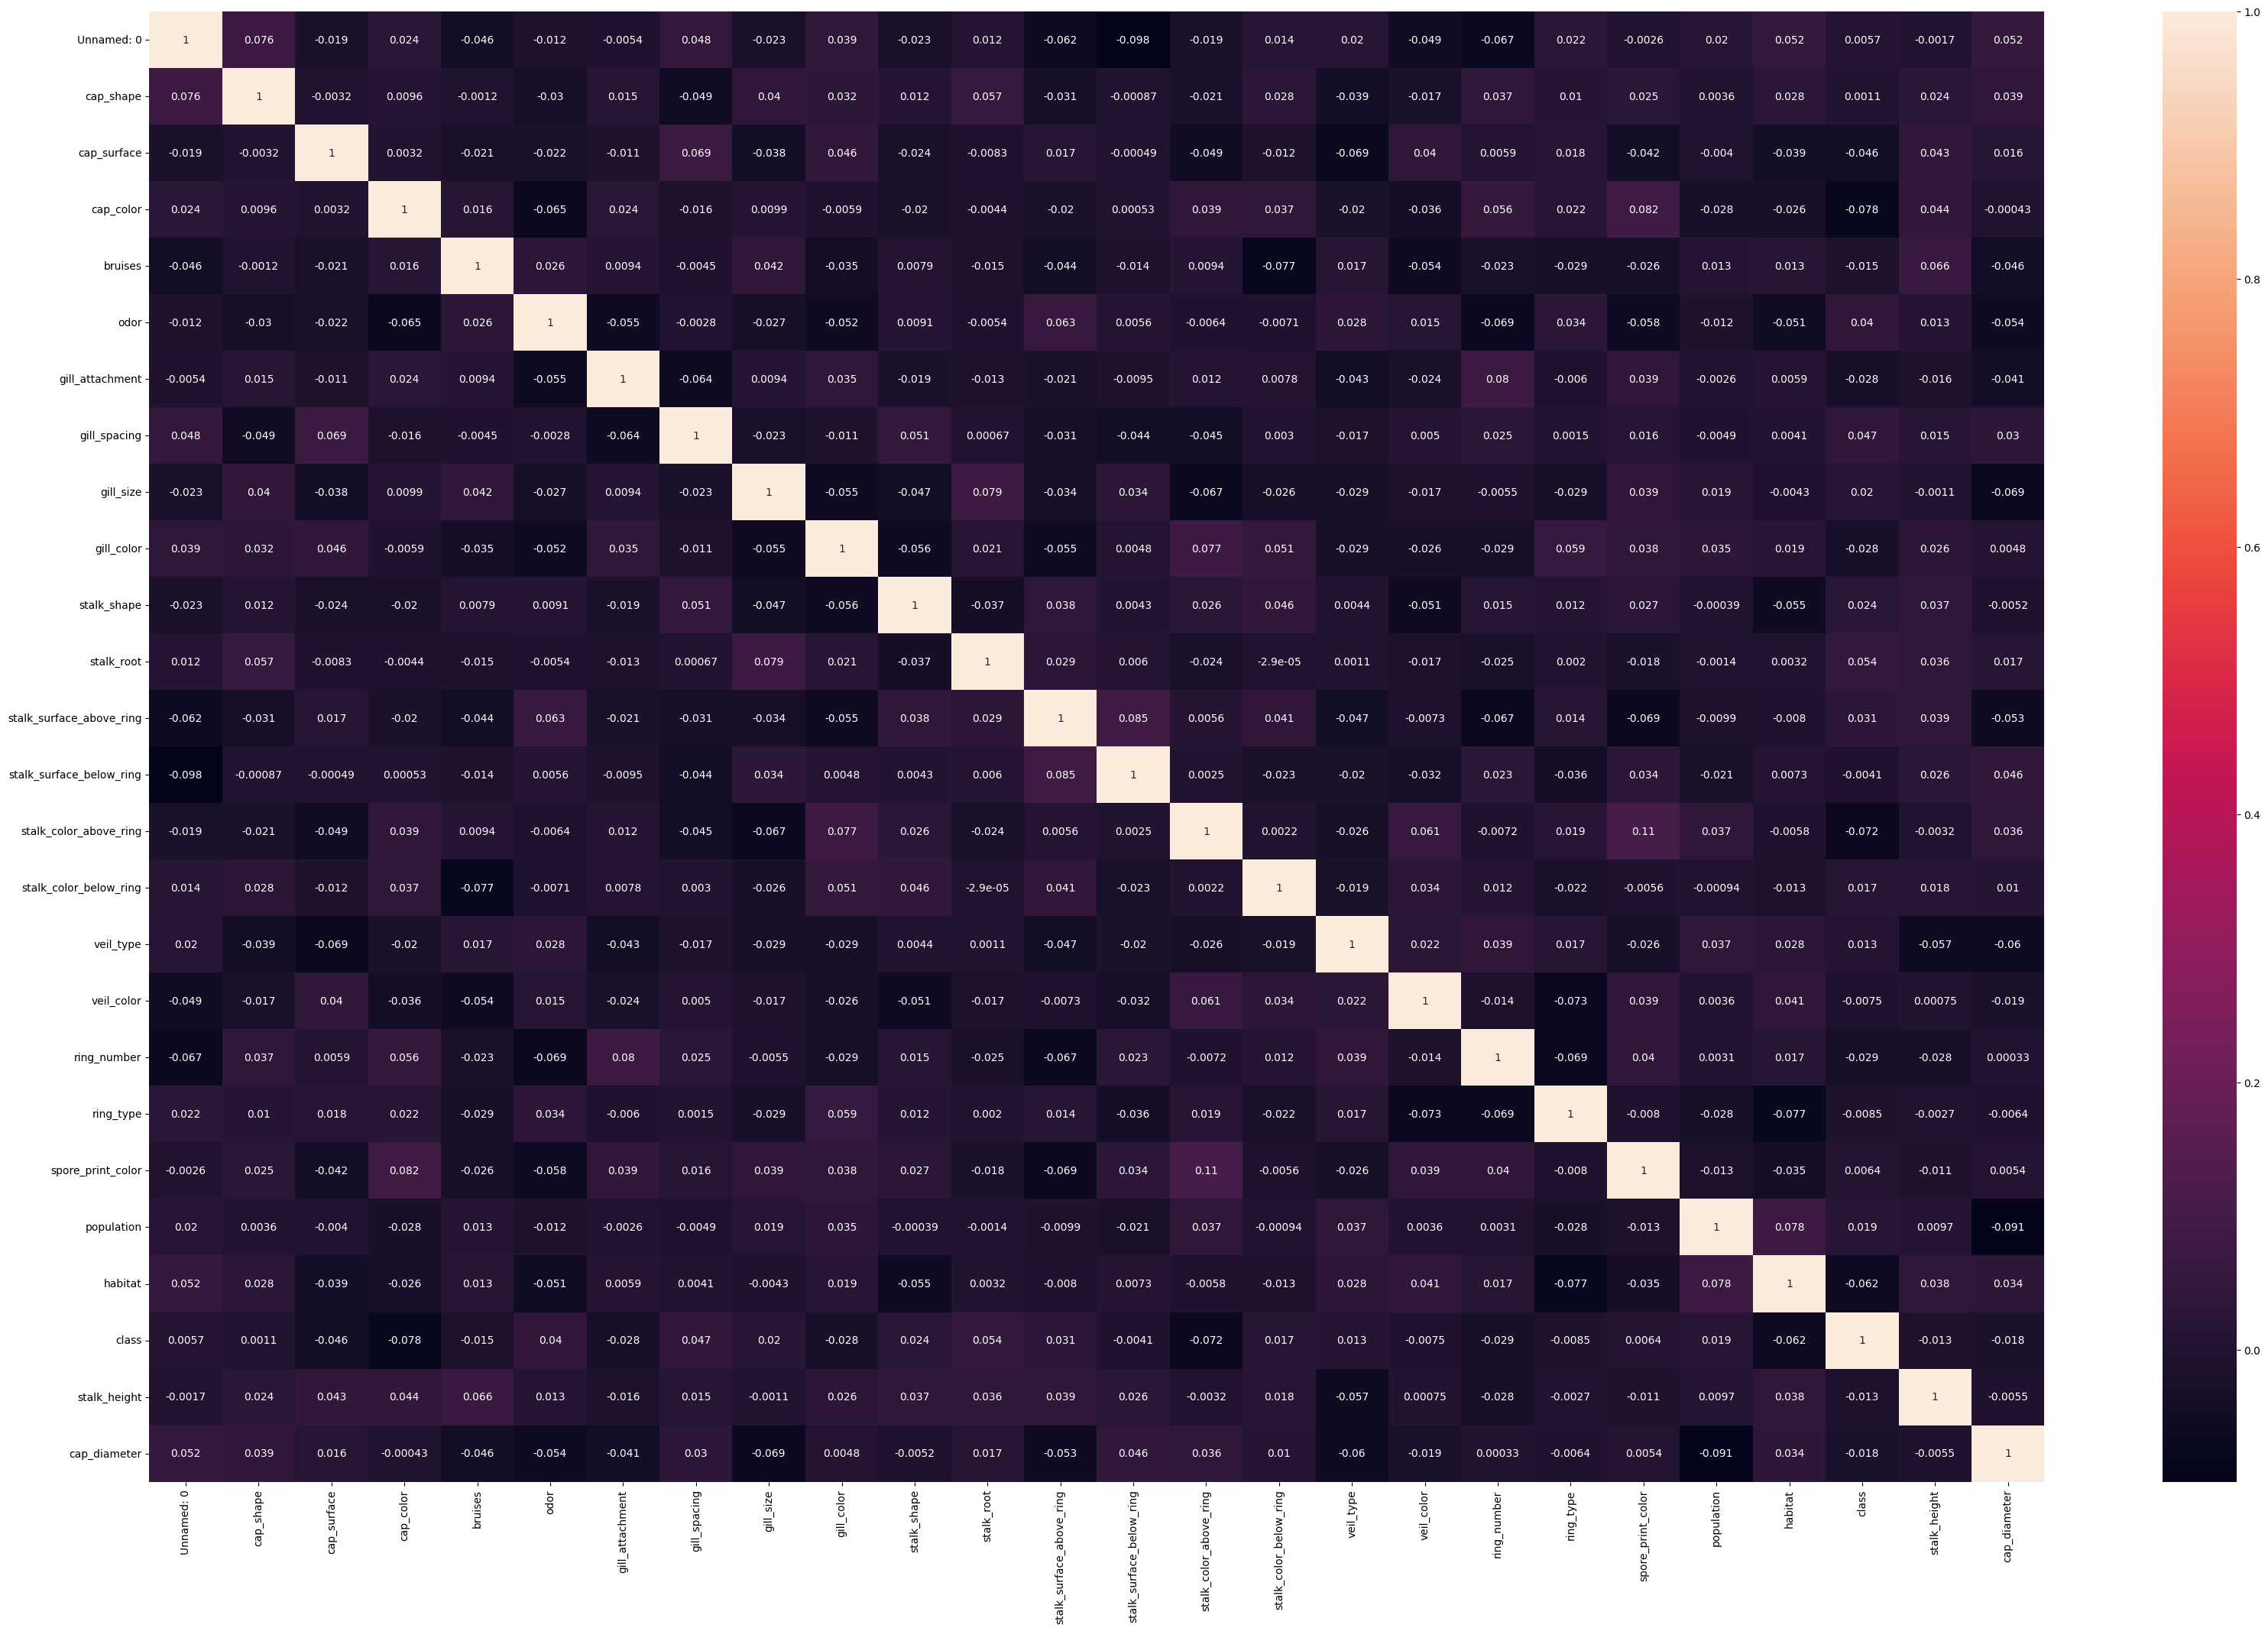

In [ ]:
#Task 1 : 3. Correlation heatmap
import seaborn as sns
corr=df.corr()
plt.figure(figsize=(40,25))
sns.heatmap(corr,annot=True)
plt.show()

In [ ]:
#Task 2 : Data Preprocessing

In [ ]:
# Step 2: Split Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#step 1: Visualize features Distributions and Relationships
#plotting pairplot
import seaborn as sns
sns.pairplot(df)
plt.show()

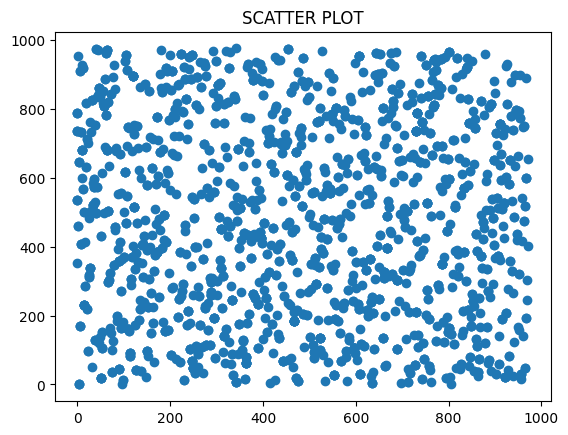

In [ ]:
#scatter plot
plt.scatter(df['stalk_height'],df['cap_diameter'])
plt.title('SCATTER PLOT')
plt.show()

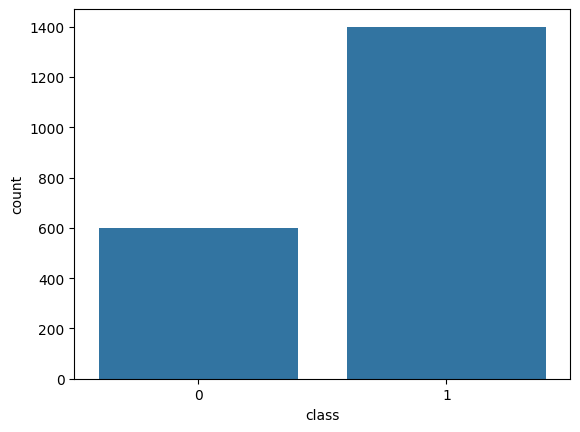

In [ ]:
# Step 2: Visualize Class Distribution
sns.countplot(x='class',data=df)
plt.show()

In [ ]:
#Task 4: SVM Implementation

In [ ]:
# step 1: Implement Basic SVM Classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
# Step 2: Model Evaluation
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6675
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400



In [ ]:
# Task 5: Visualization of SVM Results

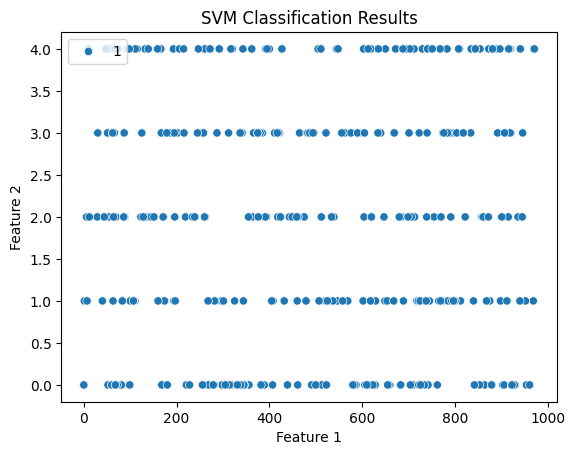

In [ ]:
# Visualize Classification Results
sns.scatterplot(x=X_test.iloc[:, 0], y=X_test.iloc[:, 1], hue=y_pred)
plt.title('SVM Classification Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# Step 1: Experiment with different SVM hyperparameters
from sklearn.model_selection import GridSearchCV
params={
    'kernel':['rbf'],
    'gamma':['scale'],
    'C':[0.1, 1, 10, 100]

}
grid=GridSearchCV(estimator=svm_model,param_grid=params)
grid.fit(X_train,y_train)

GridSearchCV(estimator=SVC(kernel='linear'),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale'],
                         'kernel': ['rbf']})

In [ ]:
print("Best parameters:", grid.best_params_)
print("Best Estimator:", grid.best_estimator_)

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Estimator: SVC(C=0.1)


In [ ]:
# Retrain SVM with best parameters
best_svm_model = grid.best_estimator_
best_svm_model.fit(X_train, y_train)

SVC(C=0.1)

In [ ]:
# Evaluate model performance
y_pred_best = best_svm_model.predict(X_test)
accuracy_best = accuracy_score(y_test,y_pred_best)
print("Accuracy (Best parameters):",accuracy_best)
print("Classification Report (Best parameters):\n", classification_report(y_test,y_pred_best))

Accuracy (Best parameters): 0.6675
Classification Report (Best parameters):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400



In [ ]:
# Step 1: Compare SVM performance with different kernels
svm_kernels = ['linear', 'poly', 'rbf']
for kernel in svm_kernels:
    svm_model = SVC(kernel=kernel)
    svm_model.fit(X_train, y_train)
    y_pred_kernel = svm_model.predict(X_test)
    accuracy_kernel = accuracy_score(y_test, y_pred_kernel)
    print("Kernel:", kernel)
    print("Accuracy:", accuracy_kernel)
    print("Classification Report:\n", classification_report(y_test, y_pred_kernel))
    print()

Kernel: linear
Accuracy: 0.6675
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400


Kernel: poly
Accuracy: 0.6675
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400


Kernel: rbf
Accuracy: 0.6675
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy     

In [ ]:
# Step 2: Analyze SVM strengths and weaknesses
# - Linear kernel might perform well with high-dimensional datasets like the Mushroom dataset.
# - Polynomial and RBF kernels might capture more complex relationships but could be prone to overfitting.

# Step 3: Discuss practical implications
# - SVM can be used for classification tasks where the decision boundary is not necessarily linear.
# - SVM's ability to handle high-dimensional data and nonlinear relationships makes it suitable for various real-world applications, including image recognition, text classification, and bioinformatics.